In [1]:
import numpy as np
import pandas as pd

import statsmodels.api as sm

import seaborn as sns
import matplotlib.pylab as plt

from sklearn.metrics import r2_score as r2
from sklearn.metrics import mean_absolute_percentage_error as mape

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

Есть данные о продажах, остатках, закупках по клиентам за период неполных два года
Хотим прогнозировать продажи с учетом сезонности, остатков и закупок
Метод выбрали Категориальный бустинг, чтобы наименование клиента передать как категориальный признак
Сезонность продаж зависит от месяца - поэтому он тоже пойдет как категория
Числовыми признаками будут -  номер периода, остатки, закупки

In [2]:
#! pip install catboost
from catboost import CatBoostRegressor

In [3]:
df = pd.read_excel('Case_Analyst_Решение.xlsx', sheet_name  = 'data').fillna(0)
df.head()

,Период,Клиент,Продажи,Остатки,Закупки
0,2020-01-01,Григорий,1.680468e+08,2.994128e+08,2.095030e+08
1,2020-02-01,Григорий,2.036499e+08,3.381993e+08,1.539659e+08
2,2020-03-01,Григорий,2.566368e+08,3.322793e+08,3.491804e+08
3,2020-04-01,Григорий,2.317790e+08,4.224878e+08,2.521181e+08
4,2020-05-01,Григорий,1.952722e+08,3.031453e+08,1.931633e+08


In [4]:
#отделяю актуальные данные на которых буду учить и валидировать модель
df_actual = df[(df['Период'] < '2021-10')].copy()
df_actual.tail()

,Период,Клиент,Продажи,Остатки,Закупки
136,2021-05-01,Другие,7.570116e+08,3.995233e+08,1.652844e+08
137,2021-06-01,Другие,8.973925e+08,3.999651e+08,1.918143e+08
138,2021-07-01,Другие,8.957503e+08,4.479332e+08,1.144805e+08
139,2021-08-01,Другие,8.427083e+08,4.091580e+08,1.630058e+08
140,2021-09-01,Другие,9.661186e+08,3.669062e+08,1.828301e+08


In [5]:
#меняю дату на номер периода чтобы использовать как фичу
df_actual['Номер_периода'] = df_actual.groupby('Клиент')['Период'].rank(method='max')

#месяц тоже нужен как влияющий на продажи фактор (сезонность)
df_actual['Месяц'] = df_actual['Период'].dt.month.astype('object')


df_actual.tail()

,Период,Клиент,Продажи,Остатки,Закупки,Номер_периода,Месяц
136,2021-05-01,Другие,7.570116e+08,3.995233e+08,1.652844e+08,17.0,5
137,2021-06-01,Другие,8.973925e+08,3.999651e+08,1.918143e+08,18.0,6
138,2021-07-01,Другие,8.957503e+08,4.479332e+08,1.144805e+08,19.0,7
139,2021-08-01,Другие,8.427083e+08,4.091580e+08,1.630058e+08,20.0,8
140,2021-09-01,Другие,9.661186e+08,3.669062e+08,1.828301e+08,21.0,9


In [6]:
df_actual.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 126 entries, 0 to 140
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Период         126 non-null    datetime64[ns]
 1   Клиент         126 non-null    object        
 2   Продажи        126 non-null    float64       
 3   Остатки        126 non-null    float64       
 4   Закупки        126 non-null    float64       
 5   Номер_периода  126 non-null    float64       
 6   Месяц          126 non-null    object        
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 7.9+ KB


In [7]:
#делю на тест и трейн, затем тест еще на тест и валидацию для контроля переобучения модели в соотношении 60\20\20
train, test = train_test_split(df_actual,train_size=0.8,random_state=42)

val, test = train_test_split(test, train_size=0.5,random_state=42)


In [8]:
#список фичей
X = ['Номер_периода','Месяц','Клиент','Остатки','Закупки']

#из них категориальные
cat_features = ['Месяц','Клиент']

#целевая переменная - что хотим предсказывать
y = ['Продажи']

In [9]:
#обучаем модель на трейне с целевой метрикой MAPE, валидация для контроля переобучения на валидационном множестве
#выводить на просмотр каждую 100 итерацию алгоритма
#по умолчанию алгоритм пройдет 1000 итераций
model = CatBoostRegressor(cat_features=cat_features,
                          eval_metric='MAPE',
                          random_seed=42,
                          verbose=100)

model.fit(train[X],train[y],eval_set=(val[X],val[y]))

Learning rate set to 0.035473
0:	learn: 0.6672904	test: 0.9769368	best: 0.9769368 (0)	total: 168ms	remaining: 2m 47s
100:	learn: 0.2443654	test: 0.3000888	best: 0.3000888 (100)	total: 2.62s	remaining: 23.3s
200:	learn: 0.1497616	test: 0.2299954	best: 0.2299954 (200)	total: 5.3s	remaining: 21.1s
300:	learn: 0.1008075	test: 0.2143059	best: 0.2143059 (300)	total: 8s	remaining: 18.6s
400:	learn: 0.0794897	test: 0.2054409	best: 0.2053971 (399)	total: 10.7s	remaining: 15.9s
500:	learn: 0.0626466	test: 0.2014763	best: 0.2014483 (496)	total: 13.4s	remaining: 13.3s
600:	learn: 0.0497040	test: 0.2005207	best: 0.2005054 (599)	total: 16.2s	remaining: 10.7s
700:	learn: 0.0387351	test: 0.2024124	best: 0.2005054 (599)	total: 19s	remaining: 8.09s
800:	learn: 0.0313423	test: 0.2015991	best: 0.2005054 (599)	total: 21.7s	remaining: 5.38s
900:	learn: 0.0261878	test: 0.2013861	best: 0.2005054 (599)	total: 24.3s	remaining: 2.67s
999:	learn: 0.0213115	test: 0.2004458	best: 0.2002628 (944)	total: 26.9s	remain

In [10]:
#точка останова итеративной модели
model.best_iteration_

944

In [11]:
#скорость обучения модели
model.learning_rate_

0.03547300025820732

In [12]:
#оцениваем качество прогноза на трейне
train['Продажи_прогноз'] = model.predict(train[X])

print('Ошибка прогноза на трейне:',mape(train['Продажи'],train['Продажи_прогноз']))

Ошибка прогноза на трейне: 0.1014385974929361


In [13]:
#прогнозируем обученной моделью на тесте
test['Продажи_прогноз'] = model.predict(test[X])

print('Ошибка прогноза на тесте:',mape(test['Продажи'],test['Продажи_прогноз']))

Ошибка прогноза на тесте: 0.239462057200235


In [14]:
#Переобучим модель на более полных данных - (трейн + вал), ди сих пор валидация использовалась для контроля переобучения модели
#Здесь валидации уже не будет
train_full = pd.concat([train,val])

#Парметры модели из результатов обучения
parameters = {'iterations': model.best_iteration_ + 1,
              'cat_features': cat_features,
              'eval_metric': 'MAPE',
              'learning_rate': model.learning_rate_,
              'random_seed':42,
              'verbose':100}

model = CatBoostRegressor(**parameters)

#обучение на полных данных
model.fit(train_full[X],train_full[y])

0:	learn: 0.6848640	total: 13.9ms	remaining: 13.1s
100:	learn: 0.2203494	total: 2.45s	remaining: 20.5s
200:	learn: 0.1348061	total: 5.13s	remaining: 19s
300:	learn: 0.0976613	total: 7.87s	remaining: 16.8s
400:	learn: 0.0754225	total: 10.6s	remaining: 14.3s
500:	learn: 0.0624195	total: 13.2s	remaining: 11.7s
600:	learn: 0.0507332	total: 15.9s	remaining: 9.1s
700:	learn: 0.0423827	total: 18.6s	remaining: 6.47s
800:	learn: 0.0358490	total: 21.3s	remaining: 3.83s
900:	learn: 0.0300814	total: 24.1s	remaining: 1.18s
944:	learn: 0.0284716	total: 25.2s	remaining: 0us


In [15]:
#оцениваем качество прогноза на трейне
train['Продажи_новый_прогноз'] = model.predict(train[X])

print('Ошибка нового прогноза на трейне:',mape(train['Продажи'],train['Продажи_новый_прогноз']))

Ошибка нового прогноза на трейне: 0.08519065846254362


In [16]:
#прогнозируем переобученной на полных данных моделью на тесте
test['Продажи_новый_прогноз'] = model.predict(test[X])
print('Ошибка нового прогноза на тесте:',mape(test['Продажи'],test['Продажи_новый_прогноз']))

Ошибка нового прогноза на тесте: 0.1817976379595769


АНАЛИЗ ОШИБОК


<Axes: >

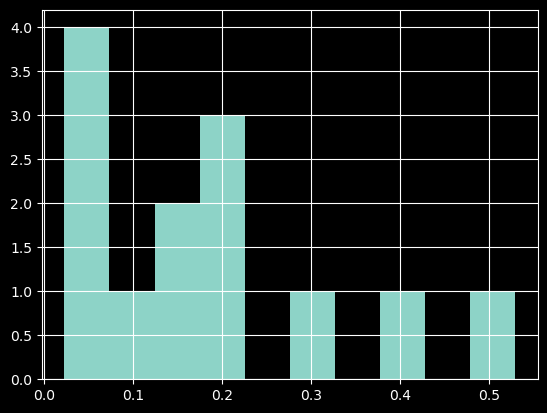

In [21]:
#темный график
plt.style.use('dark_background')

test['error%'] = abs(test['Продажи'] - test['Продажи_новый_прогноз'])/test['Продажи']
test['error%'].hist()

In [22]:
test['error%'].describe()

count    13.000000
mean      0.181798
std       0.148304
min       0.022364
25%       0.050662
50%       0.161401
75%       0.207835
max       0.529149
Name: error%, dtype: float64

In [23]:
test.sort_values('error%',ascending=False).head(5)

,Период,Клиент,Продажи,Остатки,Закупки,Номер_периода,Месяц,Продажи_прогноз,Продажи_новый_прогноз,error,error%
103,2020-08-01,Павел,5.036224e+08,8.304585e+08,4.111579e+08,8.0,8,7.858985e+08,7.701135e+08,2.664911e+08,0.529149
0,2020-01-01,Григорий,1.680468e+08,2.994128e+08,2.095030e+08,1.0,1,2.705235e+08,2.321941e+08,6.414733e+07,0.381723
62,2021-03-01,Петр,9.227956e+08,1.122272e+09,1.078734e+09,15.0,3,6.157377e+08,6.635601e+08,2.592355e+08,0.280924
131,2020-12-01,Другие,1.175104e+09,2.773840e+08,2.115421e+08,12.0,12,8.453705e+08,9.308759e+08,2.442283e+08,0.207835
86,2021-03-01,Федор,1.742221e+08,1.321663e+09,9.033375e+08,15.0,3,1.941563e+08,2.104226e+08,3.620051e+07,0.207784


In [37]:
test_estimates = test.assign(std_sales = test.groupby('Клиент')['Продажи'].transform('std'),
                             std_stocks = test.groupby('Клиент')['Остатки'].transform('std'),
                             std_sales_in = test.groupby('Клиент')['Закупки'].transform('std') )

#списко показателей, которые могу влиять на ошбку прогноза
estimated_columns = ['Продажи','Остатки','Закупки','error%','std_sales','std_stocks','std_sales_in']

<Axes: >

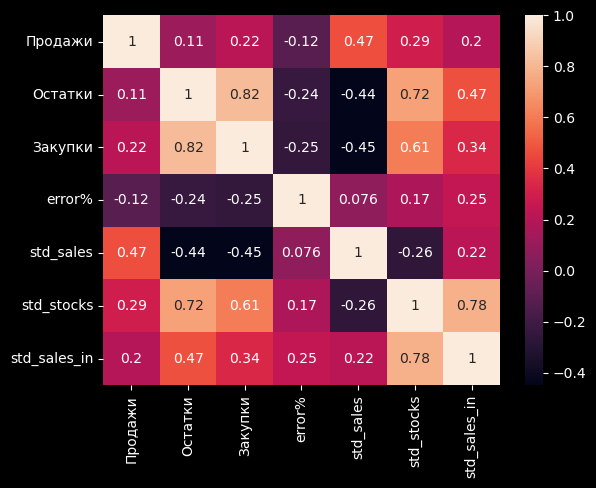

In [39]:
#как влияют друг на друга показатели и от чего зависит ошибка?
sns.heatmap(test_estimates[estimated_columns].corr(), annot = True)

Важность факторов для прогноза


In [40]:
model.get_feature_importance(prettified=True)

,Feature Id,Importances
0,Клиент,46.747041
1,Месяц,18.621369
2,Закупки,12.771099
3,Остатки,12.183095
4,Номер_периода,9.677395


In [42]:
#визуализация факторов влияния на результат прогноза
#! pip install shap
import shap
shap.initjs()

In [53]:
print('Средние фактические продажи трейна',round(train['Продажи'].mean(),0))
print('Средние прогнозируемые продажи трейна',round(train['Продажи_новый_прогноз'].mean(),0))
print('Средние фактические продажи теста',round(test['Продажи'].mean(),0))
print('Средние прогнозируемые продажи теста',round(test['Продажи_новый_прогноз'].mean(),0))

Средние фактические продажи трейна 577578550.0
Средние прогнозируемые продажи трейна 572352993.0
Средние фактические продажи теста 574700265.0
Средние прогнозируемые продажи теста 580953449.0


In [48]:
explainer = shap.TreeExplainer(model)
#факторы влияния на результат модели
shap_values = explainer.shap_values(test[X])
#визуализация влияния факторов на прогноз (что увеличило и что уменьшило результат относительно среднего прогноза)
shap.force_plot(explainer.expected_value, shap_values[0,:], test[X].iloc[0,:])
#видим объяснение результата прогноза произвольно выбранной строки

In [56]:
#делаем таблицу из факторов влияния на результат
shap_cols = [x+'_shap' for x in X]
shap_values_df = pd.DataFrame(shap_values,columns=shap_cols)
shap_values_df.head()

,Номер_периода_shap,Месяц_shap,Клиент_shap,Остатки_shap,Закупки_shap
0,2.083245e+07,-5.114116e+07,1.676096e+08,2.136909e+07,-1.432602e+06
1,2.106144e+06,3.937873e+07,1.818340e+08,1.865318e+07,-3.907725e+07
2,-2.194667e+07,1.705915e+07,-3.259103e+08,-3.710312e+07,1.492104e+07
3,-2.475830e+07,4.747363e+07,7.230495e+07,-1.561365e+07,1.693475e+07
4,2.598694e+07,1.329225e+07,2.450340e+08,-4.313084e+07,7.325941e+07


In [61]:
#присоединяем справа к тестовой таблце с данными таблицу факторов влияния на результат
test_shap = pd.concat([test.reset_index(),shap_values_df],axis=1)
#сортируем по убыванию ошбок
test_shap = test_shap.sort_values('error%',ascending=False)
test_shap.head()

,index,Период,Клиент,Продажи,Остатки,Закупки,Номер_периода,Месяц,Продажи_прогноз,Продажи_новый_прогноз,error,error%,Номер_периода_shap,Месяц_shap,Клиент_shap,Остатки_shap,Закупки_shap
1,103,2020-08-01,Павел,5.036224e+08,8.304585e+08,4.111579e+08,8.0,8,7.858985e+08,7.701135e+08,2.664911e+08,0.529149,2.106144e+06,3.937873e+07,1.818340e+08,1.865318e+07,-3.907725e+07
8,0,2020-01-01,Григорий,1.680468e+08,2.994128e+08,2.095030e+08,1.0,1,2.705235e+08,2.321941e+08,6.414733e+07,0.381723,-4.121158e+07,-3.435636e+07,-2.405672e+08,-1.913363e+06,-1.697611e+07
3,62,2021-03-01,Петр,9.227956e+08,1.122272e+09,1.078734e+09,15.0,3,6.157377e+08,6.635601e+08,2.592355e+08,0.280924,-2.475830e+07,4.747363e+07,7.230495e+07,-1.561365e+07,1.693475e+07
10,131,2020-12-01,Другие,1.175104e+09,2.773840e+08,2.115421e+08,12.0,12,8.453705e+08,9.308759e+08,2.442283e+08,0.207835,5.677544e+06,1.204914e+08,1.916832e+08,4.109685e+07,4.708189e+06
9,86,2021-03-01,Федор,1.742221e+08,1.321663e+09,9.033375e+08,15.0,3,1.941563e+08,2.104226e+08,3.620051e+07,0.207784,-1.252647e+07,4.116960e+07,-3.516286e+08,-5.120537e+07,1.739470e+07


In [64]:
#визуализация факторов влияния на прогноз с максимальной ошибкой
shap.initjs()
shap.force_plot(explainer.expected_value, test_shap[shap_cols].values[0,:], test_shap[X].iloc[0,:])

In [65]:
#визуализация факторов влияния на топ 10 ошибок
shap.initjs()
shap.force_plot(explainer.expected_value, test_shap[shap_cols].head(10).values,
                                          test_shap[X].head(10))

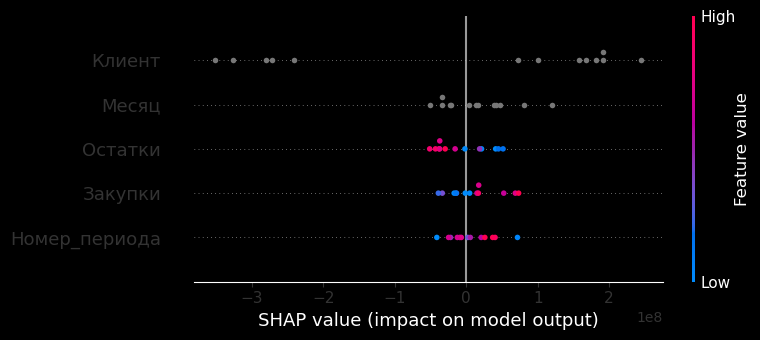

In [74]:
#визуализация вклада всех фичей одновременно на результатп редсказания модели
#вертикальная ось показывает соответствие цвета и динамики (возрастание, убывание)
shap.summary_plot(shap_values, test[X])

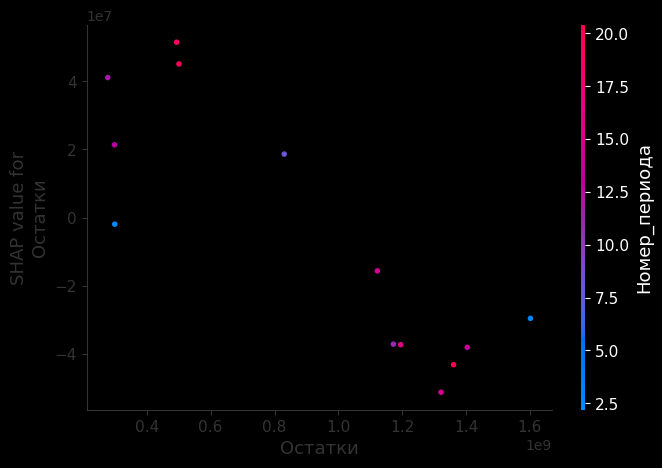

In [76]:
#по каждому фактору отдельно посмотрим его влияние на прогноз модели
#как остатки влияют на предсказание модели, вторая переменная будет выбрана автоматически (номер периода)
shap.dependence_plot("Остатки", shap_values, test[X])

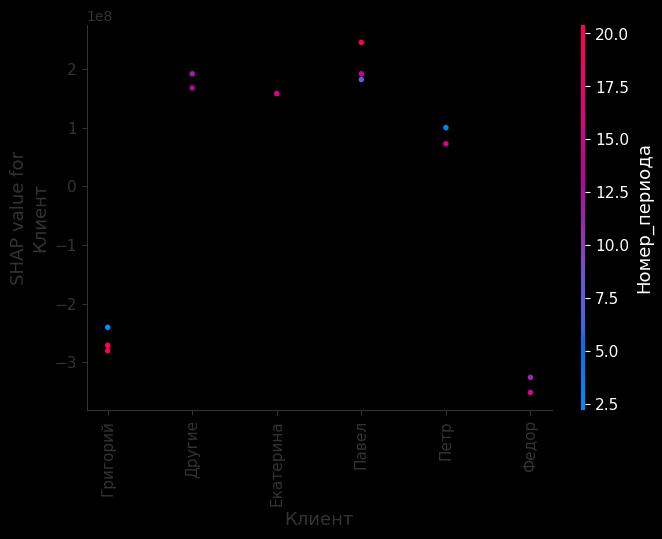

In [77]:
#как категориальная переменная Клиент влияют на предсказание модели
shap.dependence_plot("Клиент", shap_values, test[X])

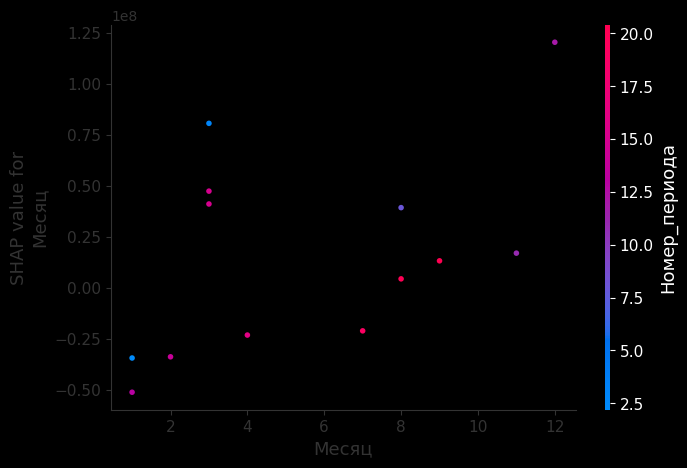

In [79]:
#как категориальная переменная Месяц влияют на предсказание модели
# это к вопросу есть ли сезонность продаж по месяцам
#видим пики продаж в марте,августе,декабре
shap.dependence_plot("Месяц", shap_values, test[X])